In [2]:
#import necessry libraries for decision trees
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,classification_report
import seaborn as sns

In [4]:
# Generate synthetic data for Decision Tree
np.random.seed(42)

# Class 0: Not Buy (e.g., Younger, Lower Income)
X_dt0 = np.random.normal(loc=[30, 40000], scale=[8, 10000], size=(60, 2))
y_dt0 = np.zeros(60)

# Class 1: Buy (e.g., Older, Higher Income)
X_dt1 = np.random.normal(loc=[50, 70000], scale=[10, 15000], size=(60, 2))
y_dt1 = np.ones(60)

# Combine data
X_dt = np.vstack((X_dt0, X_dt1))
y_dt = np.hstack((y_dt0, y_dt1))

df_dt = pd.DataFrame(X_dt, columns=['Age' , 'Income'])
df_dt['Buy'] = y_dt

print(df_dt)

           Age        Income  Buy
0    33.973713  38617.356988  0.0
1    35.181508  55230.298564  0.0
2    28.126773  37658.630431  0.0
3    42.633703  47674.347292  0.0
4    26.244205  45425.600436  0.0
..         ...           ...  ...
115  42.696334  73246.878844  1.0
116  50.455718  60225.994786  1.0
117  71.439441  79508.785335  1.0
118  29.748574  72796.814722  1.0
119  43.382135  82786.500022  1.0

[120 rows x 3 columns]


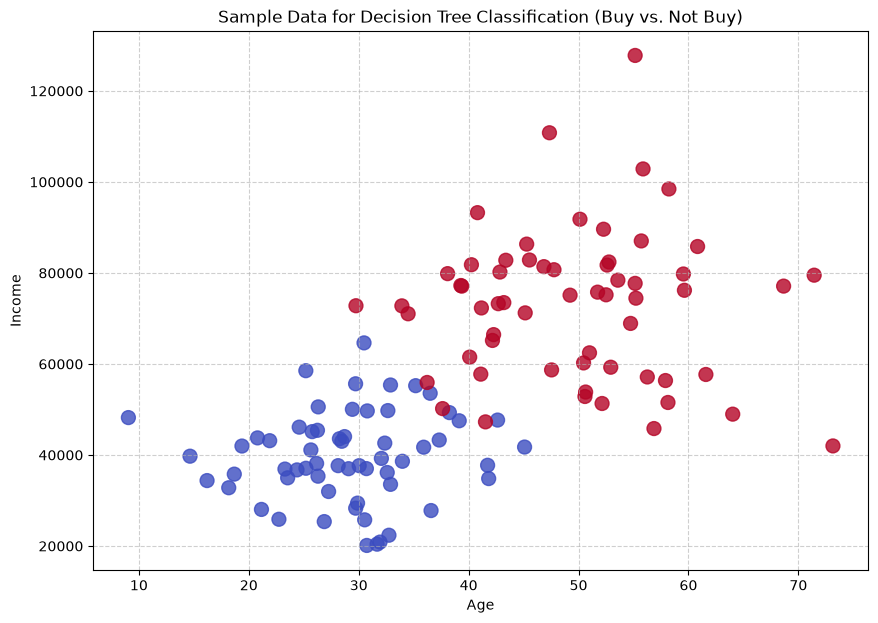

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(df_dt["Age"], df_dt["Income"],
            c=df_dt["Buy"], cmap="coolwarm",
            s=100, alpha=0.8)

plt.title("Sample Data for Decision Tree Classification (Buy vs. Not Buy)")
plt.xlabel("Age")
plt.ylabel("Income")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

In [11]:
from sklearn.model_selection import train_test_split

# Split data for Decision Tree
X = df_dt[['Age', 'Income']]
y = df_dt['Buy']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape for DT:", X_train.shape, y_train.shape)
print("Testing set shape for DT:", X_test.shape, y_test.shape)

Training set shape for DT: (96, 2) (96,)
Testing set shape for DT: (24, 2) (24,)


In [12]:
dt_classifier = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

dt_classifier.fit(X_train, y_train)

y_pred = dt_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Classifier Accuracy: {accuracy:.2f}")

Decision Tree Classifier Accuracy: 0.96


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Split the data
X_dt_train, X_dt_test, y_dt_train, y_dt_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the model
dt_classifier.fit(X_dt_train, y_dt_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


In [16]:
# Make predictions on the test data
y_pred = dt_classifier.predict(X_test)

print("First 10 actual labels for DT:", y_test[:10])
print("First 10 predicted labels for DT:", y_pred[:10])

First 10 actual labels for DT: 44     0.0
47     0.0
4      0.0
55     0.0
26     0.0
64     1.0
73     1.0
10     0.0
40     0.0
107    1.0
Name: Buy, dtype: float64
First 10 predicted labels for DT: [0. 0. 0. 0. 0. 1. 0. 0. 0. 1.]


In [19]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluate the Decision Tree model
dt_accuracy = accuracy_score(y_test, y_pred)
dt_report = classification_report(y_test, y_pred)

print(f"Decision Tree Accuracy: {dt_accuracy:.2f}")
print("Decision Tree Classification Report:\n", dt_report)

Decision Tree Accuracy: 0.96
Decision Tree Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      1.00      0.96        13
         1.0       1.00      0.91      0.95        11

    accuracy                           0.96        24
   macro avg       0.96      0.95      0.96        24
weighted avg       0.96      0.96      0.96        24

